### Team Analysis

We will now investigate team's dependencies on each player and how well the use the ball. To do this we will investigate a player's usage rate, the number of PEA a player has as a proportion of their team's total PEA. Since this is a percentage, we will see how this affects a player's attacking involvement, defined as a players SCA as a percentage of their team's total SCA.

From the resulting figures, we will be able to analyse team's dependencies on specific players and how this aligns with their tactical systems and how effective each player within the team is with their share of possessions. 

In [2]:
# 1: Load and split the data
import pandas as pd
from pathlib import Path

# Data folders
project_folder = Path.cwd().parent 
player_data = pd.read_csv(project_folder / "data" / "player_usage_data.csv")

In [266]:
# 2: Create a reusable function to analyse specific teams
import matplotlib.pyplot as plt

def plot_team_usage(team_name, team_colour):

    # Find the team specific data
    team_data = player_data[player_data["teamName"] == team_name].copy()

    # Create combined GA column
    team_data["GA"] = team_data["goals"] + team_data["assists"]

    # Remove players with less than 5 matches played
    team_data = team_data[team_data["minutesPlayed"] >= 450]

    # Define default font
    plt.rcParams["font.family"] = "DIN Alternate"
    
    # Initialise the figure
    fig,ax = plt.subplots(1,1, figsize = (12,6), facecolor = "#404040")

    # Define the marker sizes
    sizes = 10 + team_data["GA"] * 40

    # Plot the data
    ax.scatter(team_data["usageRate"] * 100,
               team_data["attackingInvolvement"] *100,
               s = sizes,
               c = team_colour,
               alpha = 0.8,
               edgecolor = "#CCCCCC",
               linewidth = 0.5)

    # Figure customisation
    ax.set_title(f"{team_name} Player Usage Rates",
                      fontsize = 16,
                      pad = 10,
                      color = "white",
                      loc = "left")
    ax.set_xlabel("Usage Rate %",
                      fontsize = 12,
                      color = "#CCCCCC")
    ax.set_ylabel("Attacking Involvement %",
                      fontsize = 12,
                      color = "#CCCCCC")
    ax.set_facecolor("#404040")
    ax.tick_params(axis = "both",
                  labelsize = 12,
                  labelcolor = "#CCCCCC",
                  color = "#CCCCCC")
    for spine in ax.spines.values():
        spine.set_color("#CCCCCC")
        spine.set_linewidth(1)

    
    # Annotate player names
    for _, player in team_data.iterrows():

        ax.annotate(
            player["playerName"],
            (player["usageRate"] *100, player["attackingInvolvement"]*100),
            xytext = (0, -12),
            ha = "center",
            textcoords = "offset points",
            fontsize = 8,
            color = "#CCCCCC")

    # Plot an x=y line
    max_value = max((team_data["usageRate"]*100).max(),
                   (team_data["attackingInvolvement"]*100).max())
    ax.plot([0,max_value],
            [0, max_value],
            linestyle = "--",
            linewidth = 1,
            color = "#CCCCCC")

    #
    plt.savefig(project_folder / "figures" / "teams" / f"{team_name}-usage-rates.png",
               format = "png",
               dpi = 150)
    plt.show()

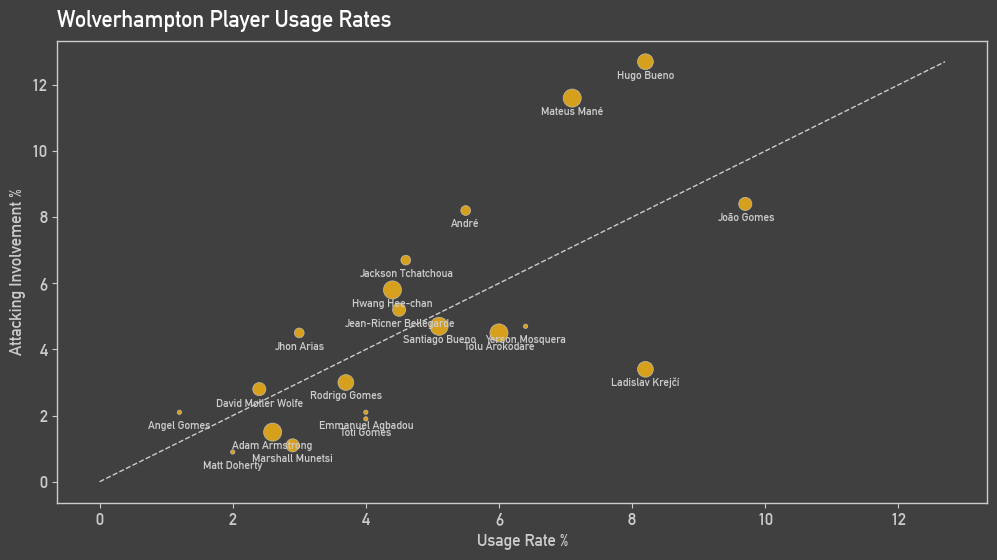

In [308]:
plot_team_usage("Wolverhampton", "#FDB913")